In [167]:
import torch

def quick_white_matter_mask(brain_volume):
    """
    brain_volume: A 3D or 2D PyTorch tensor of a skull-stripped T1 MRI.
    Returns a binary mask of the brightest tissue (assumed to be White Matter).
    """
    # 1. Flatten the image and remove background (0 intensity)
    pixels = brain_volume.view(-1)
    brain_pixels = pixels[pixels > 0.05] # Adjust threshold if background is noisy

    if len(brain_pixels) == 0:
        return torch.zeros_like(brain_volume)

    # 2. Find the intensity threshold for the top ~30% brightest pixels
    # (White matter roughly makes up the top intensity band in a T1)
    # This is a fast, statistical hack instead of formal clustering
    threshold = torch.quantile(brain_pixels, 0.7)

    # 3. Create the binary mask
    wm_mask = (brain_volume > threshold).float()

    return wm_mask

In [206]:
import torch

def slice_by_slice_white_matter_mask(brain_volume):
    """
    brain_volume: A 3D PyTorch tensor (Num_Images, Height, Width).
    Returns a binary mask calculated image-by-image.
    """
    # Create an empty volume to store our final masks
    wm_mask_volume = torch.zeros_like(brain_volume)

    # Loop through each image/slice in the volume (axis 0)
    for i in range(brain_volume.shape[0]):
        single_image = brain_volume[i]

        # 1. Isolate the brain pixels for THIS specific image
        pixels = single_image.view(-1)
        brain_pixels = pixels[pixels > 0.05]

        # If the image is just empty background, skip it
        if len(brain_pixels) == 0:
            continue

        # 2. Find the threshold for THIS specific image
        # (Using 0.7 here gives you the threshold for the TOP 30% brightest pixels)
        threshold = torch.quantile(brain_pixels, 0.55)

        # 3. Create the binary mask and store it in our final volume
        wm_mask_volume[i] = (single_image > threshold).float()

    return wm_mask_volume

In [207]:
# from dataloader import *
#
# train_image_path = '/shared/anastasio-s2/SI/HCP_selected/{}/train/data.h5'.format('sks_3.0_0.2_25.0_c2_num_signals_diffusion_n')
#
# train_dataset = MRIDataset1_2(train_image_path)
#
# train_dataloader = DataLoader(
#     train_dataset,  # Your dataset
#     batch_size=128,  # Batch size (samples per batch)
#     shuffle=False,  # Whether to shuffle data
#     drop_last=True,  # Drop incomplete batches
#     num_workers=4,  # Number of CPU processes for data reading
#     pin_memory=True,  # Accelerate CPU->GPU copy
#     persistent_workers=True,  # Workers do not restart repeatedly
#     prefetch_factor=8,  # How many batches to prefetch
# )

In [208]:
import numpy as np

# train_bg_path = "/shared/anastasio-s2/SOM/kaiyan/mri_1000_200k/background_train.npy"
test_bg_path = "/shared/anastasio-s2/SOM/kaiyan/mri_1000_200k/background_test.npy"

# bg_array = np.load(train_bg_path, mmap_mode='r')
bg_test_array = np.load(test_bg_path, mmap_mode='r')

# bg_array = bg_array[:, :, :, 0]
# bg_val_array = bg_test_array[:5000, :, :, 0]
# bg_test_array = bg_test_array[5000:, :, :, 0]

In [209]:
bg_test_array = bg_test_array[:1000, :, :, 0]

bg_test_array = torch.from_numpy(bg_test_array).float()

# wm_mask = quick_white_matter_mask(bg_test_array)
wm_mask = slice_by_slice_white_matter_mask(bg_test_array)

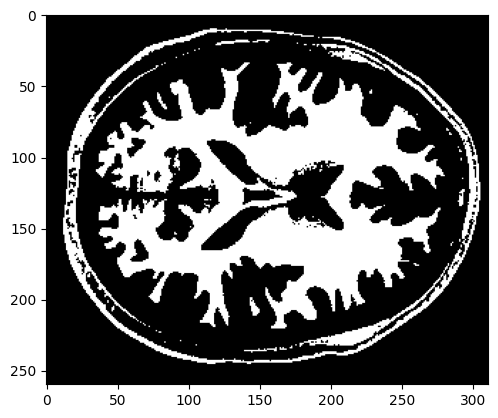

In [210]:
import matplotlib.pyplot as plt

plt.imshow(wm_mask[0], cmap='gray')

In [211]:
import torch
import numpy as np
from skimage import morphology, measure

def isolate_brain_from_tensor(wm_mask: torch.Tensor, erosion_radius: int = 3) -> torch.Tensor:
    """
    Takes a PyTorch binary mask containing a brain and a skull,
    removes the skull, and returns the cleaned PyTorch tensor.
    """
    # 1. Save original device and shape
    device = wm_mask.device
    original_dtype = wm_mask.dtype
    is_3d = (wm_mask.ndim == 3) # Check if shape is (1, H, W)

    # 2. Move to CPU and convert to a boolean NumPy array
    mask_np = wm_mask.detach().cpu().squeeze().numpy() > 0

    if not mask_np.any():
        return torch.zeros_like(wm_mask) # Return empty if no white matter exists

    # 3. Erosion (shrinks pixels to break the bridges to the skull)
    selem = morphology.disk(erosion_radius)

    eroded = morphology.binary_erosion(mask_np, selem)

    # 4. Connected Components (label every disconnected blob)
    labels = measure.label(eroded, background=0)

    if labels.max() == 0:
        return torch.zeros_like(wm_mask) # Return empty if erosion erased everything

    # 5. Find the largest component (The Brain)
    # Using np.bincount is much faster than regionprops for just finding the largest area
    counts = np.bincount(labels.ravel())
    counts[0] = 0  # Ignore the background (label 0)
    largest_label = counts.argmax()

    # Isolate only the largest blob
    brain_eroded = (labels == largest_label)

    # 6. Dilation (grow the brain back to its original size)
    brain_dilated = morphology.binary_dilation(brain_eroded, selem)

    # 7. Logical AND (intersect with original mask to perfectly restore exact edges)
    final_mask_np = brain_dilated & mask_np

    # 8. Convert back to PyTorch tensor, matching original device and data type
    final_tensor = torch.from_numpy(final_mask_np).to(device).to(original_dtype)

    # Restore channel dimension if the original had it
    if is_3d:
        final_tensor = final_tensor.unsqueeze(0)

    return final_tensor

# --- How to use it in your code ---
# cleaned_wm_mask = isolate_brain_from_tensor(wm_mask)

In [212]:
wm_mask_brain_all = np.zeros((wm_mask.shape))

for i in range(wm_mask.shape[0]):
    wm_mask_brain = isolate_brain_from_tensor(wm_mask[i])
    wm_mask_brain_all[i] = wm_mask_brain

/tmp/ipykernel_3137059/770407337.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  wm_mask_brain_all[i] = wm_mask_brain


In [213]:
# for i in range(wm_mask.shape[0]):
#     print(i)
#     plt.imshow(wm_mask[i])
#     plt.show()

In [214]:
# for i in range(wm_mask_brain_all.shape[0]):
#     print(i)
#     plt.imshow(wm_mask_brain_all[i])
#     plt.show()

In [215]:
# images = np.squeeze(wm_mask_brain_all, axis=1)

heatmap_map = np.sum(wm_mask_brain_all > 0, axis=0)

intersection_map = np.all(wm_mask_brain_all > 0, axis=0)

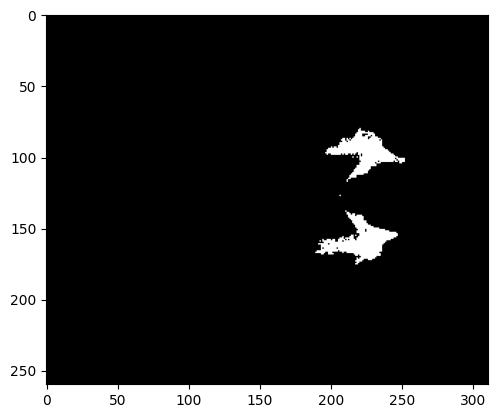

In [216]:
plt.imshow(intersection_map, cmap='gray')